# Train and Test: Scoring a Model Honestly

Last class we trained a linear regression and scored it with `model.score(X, y)`. That
grades the model on the **same rows it learned from**, which flatters it.

This notebook shows what to do instead: **hold some rows back**.

> **Note:** `nyc_rent.csv` is **invented (synthetic) data** for teaching. The patterns
> are realistic, but the rows are not real listings.

## The data

Same 300 NYC apartments as last class. We predict `rent`.

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

apts = pd.read_csv("nyc_rent.csv")
apts.head()

,size_sqft,bedrooms,subway_min,dist_manhattan_mi,building_age,days_listed,rent
0,349,0,19,7.5,16,16,1000
1,426,0,13,10.3,25,41,1325
2,675,1,16,3.2,42,30,2950
3,880,2,15,5.3,107,38,3300
4,645,1,12,11.7,62,41,1550


## The tempting mistake

Fit on every row, then score on every row. The model has already seen every answer.

In [2]:
X = apts[["size_sqft"]]
y = apts["rent"]

model = LinearRegression().fit(X, y)
print("R-squared on the training data:", round(model.score(X, y), 3))

R-squared on the training data: 0.757


That looks respectable. But it is an **open book exam**: we asked the model about
rows it had already studied. A model can partly memorize those rows.

## Hold some rows back

`train_test_split` shuffles the rows and sets a portion aside. We **fit** on the
training rows and **score** on the test rows, which the model never saw.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)      # hold back 20% of the rows

print("training rows:", len(X_train), " test rows:", len(X_test))

checked = LinearRegression().fit(X_train, y_train)   # learn here
print("train R-squared", round(checked.score(X_train, y_train), 3))
print("test  R-squared", round(checked.score(X_test,  y_test),  3))   # grade there

training rows: 240  test rows: 60
train R-squared 0.769
test  R-squared 0.703


The test score is **lower**. That gap is the part of the training score that was
flattery rather than skill.

Two arguments worth knowing:

- `test_size=0.2` holds back 20 percent of the rows. 0.2 to 0.3 is typical.
- `random_state=0` fixes the shuffle, so you get the same split every run. Without it
  your scores wobble a little each time you re-run the cell.

**Aside:** you will also see a third set, **validation**, used to compare models and
tune settings, so the test set stays sealed until the very end.

## Which rows did it actually learn from?

The split is just a division of the rows. Here the model draws its line using **only**
the training points, and is then graded on the test points it never saw.

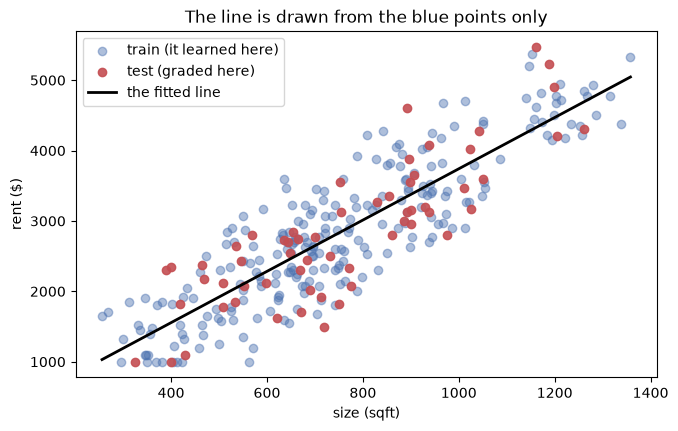

In [4]:
import matplotlib.pyplot as plt
import numpy as np

line = pd.DataFrame({"size_sqft": np.linspace(apts["size_sqft"].min(),
                                              apts["size_sqft"].max(), 100)})

plt.figure(figsize=(7.5, 4.5))
plt.scatter(X_train, y_train, alpha=0.45, color="#4c72b0", label="train (it learned here)")
plt.scatter(X_test,  y_test,  alpha=0.9,  color="#c44e52", label="test (graded here)")
plt.plot(line["size_sqft"], checked.predict(line), color="black", lw=2, label="the fitted line")

plt.xlabel("size (sqft)"); plt.ylabel("rent ($)")
plt.title("The line is drawn from the blue points only")
plt.legend()
plt.show()

The black line never saw a single red point. Scoring against those red points is the
honest test.

## More features, same habit

Add the useful columns. Nothing about the workflow changes: fit on train, report test.

In [5]:
features = ["size_sqft", "bedrooms", "subway_min", "dist_manhattan_mi", "building_age"]

X_train, X_test, y_train, y_test = train_test_split(
    apts[features], apts["rent"], test_size=0.2, random_state=0)

big = LinearRegression().fit(X_train, y_train)
print("train R-squared", round(big.score(X_train, y_train), 3))
print("test  R-squared", round(big.score(X_test,  y_test),  3))

train R-squared 0.952
test  R-squared 0.944


Both scores rose, and they sit close together. A small gap between train and test is
normal and healthy. A **large** gap is the warning sign: it means the model learned
things that only apply to the rows it studied.

## Predict a specific apartment

Describe an apartment as a one-row DataFrame with the same columns, then predict.

In [6]:
new_apt = pd.DataFrame([{
    "size_sqft": 750,
    "bedrooms": 1,
    "subway_min": 4,
    "dist_manhattan_mi": 2.5,
    "building_age": 30,
}])

print("predicted rent: $", round(big.predict(new_apt)[0]))

predicted rent: $ 3335


## The takeaway

- **Split your data** before you train. Fit on **train**, report the **test** score.
- The test score is the one that answers "will this work on data I have not seen?"
- Watch the **gap**. Train far above test means the model is memorizing.
- `random_state` keeps your split, and therefore your numbers, reproducible.